# Atera reader — exploratory analysis (R / Seurat)

Loads a sample Atera (10x Genomics next-gen in-situ) output bundle with `LoadAtera()`,
runs a BPCells-backed sketch analysis (normalization, PCA, UMAP, clustering) that scales
to whole-transcriptome, millions-of-cell bundles, and visualizes results spatially.

This is the R/Seurat counterpart to `spatialdata-io`'s `atera_example.ipynb`, adapted to
two things that matter at this scale:

- **BPCells + sketching**, not a full in-memory/full-resolution pipeline: `FindClusters`
  and `RunPCA` on the full cell count are either infeasible or take tens of minutes (see
  the "Normalization, PCA, UMAP, clustering" section below for why). Seurat5's sketch
  workflow (`SketchData`/`ProjectData`) runs the expensive steps on a small,
  statistically-representative subset of cells, then projects the results back.
- **No whole-bundle segmentation polygons or morphology image.** `sp::SpatialPolygons()`
  (cell/nucleus segmentation boundaries) and `RBioFormats` (morphology TIFFs) don't scale
  to millions of cells either — the former can overflow R's protection stack well before
  that, and the latter is eagerly decoded in full. Both are loaded here only for specific,
  cropped regions of interest, via `LoadAteraSegmentations()` and a direct morphology
  region read.

## Setup: environment, R kernel, and sample data

Run these steps **once**, in a terminal (not in this notebook), before running the cells below.

### 1. Create the R/conda environment

```bash
micromamba create -n seurat_atera -c conda-forge "r-base>=4.0" r-irkernel -y
micromamba activate seurat_atera
```

(`conda create -n seurat_atera -c conda-forge "r-base>=4.0" r-irkernel -y && conda activate seurat_atera` works the same way if you use `conda` instead of `micromamba`.)

### 2. Clone this Seurat fork (with the Atera reader)

```bash
git clone --branch stephen/atera_update https://github.com/10XGenomics/seurat.git
cd seurat
```

### 3. Install R package dependencies

```r
# Start R
>R
install.packages(c("remotes", "BiocManager"))

# Adds the Bioconductor repos alongside CRAN, so install_deps() below can resolve
# Bioconductor-hosted dependencies (RBioFormats) as well as CRAN ones.
options(repos = BiocManager::repositories())

# Installs every dependency declared in DESCRIPTION, including ones only needed for
# the Atera reader specifically (BPCells, blosc, data.table, RBioFormats, sp, ...),
# which are listed there as optional ("Suggests") from the base package's point of
# view but are required for this notebook. BPCells isn't on CRAN/Bioconductor --
# DESCRIPTION's `Additional_repositories` field (bnprks.r-universe.dev) is what lets
# install_deps() find it.
remotes::install_deps(".", dependencies = TRUE)
```

### 4. Register the Jupyter kernel

```r
IRkernel::installspec(name = "seurat_atera", displayname = "R (seurat_atera)")
```

In Jupyter/VS Code, select the **"R (seurat_atera)"** kernel for this notebook.

### 5. Download the tiny sample dataset (optional, to smoke-test your setup)

This notebook is built around a whole-transcriptome/large bundle (see the intro above) --
that's the scale its BPCells/sketching approach is actually for -- but the same reader
works on 10x Genomics' small public sample too, which is a much quicker way to confirm
your environment and code changes are working before pointing at a real, large bundle.
It lives on the 10x Genomics support site:
https://cf.10xgenomics.com/samples/atera/1.0.0/tiny_atera_dataset/tiny_atera_dataset_outs.zip
Download it with `curl`:

```bash
mkdir -p data/tiny_atera_dataset
cd data/tiny_atera_dataset
curl -O https://cf.10xgenomics.com/samples/atera/1.0.0/tiny_atera_dataset/tiny_atera_dataset_outs.zip
unzip tiny_atera_dataset_outs.zip
tar -xzvf morphology_2d.tar.gz
tar -xzvf morphology_3d.tar.gz
```

This creates a local folder containing the output bundle.

### 6. Point the notebook at your data

In the "Load data" cell below, set `BUNDLE_PATH` to whichever bundle you want to run
against. For a quick smoke test against the tiny sample:

```r
BUNDLE_PATH <- "data/tiny_atera_dataset"
```

For the real workload this notebook is built for -- a whole-transcriptome/large bundle,
where the BPCells cache and sketch-based workflow actually matter:

```r
BUNDLE_PATH <- "/path/to/your/output_bundle"
```

(Check with `ls <bundle_path>` -- it should contain files like `cell_feature_matrix.zarr.zip`,
`csc_cell_feature_matrix.zarr.zip`, `cells.zarr.zip`, `transcripts.zarr.zip`, and the
`morphology_2d`/`morphology_3d` folders.)

In [1]:
source("/Users/stephen.williams/git/seurat/notebooks/r_profiling_helpers.R")
source("/Users/stephen.williams/git/seurat/notebooks/r_resource_monitor.R")

setup_notebook_profiling()
options(vsc.dev.args = list(width = 1200, height = 1200))

suppressPackageStartupMessages({
  library(devtools)
  library(SeuratObject)
})
devtools::load_all("/Users/stephen.williams/git/seurat", quiet = TRUE)

# Match to your machine's core count -- see the "Normalization, PCA, UMAP,
# clustering" section below for which steps this actually speeds up.
setThreads(8)

Initializing R profiling system...

✓ Resource monitoring initialized
  GPU available: Yes
═══════════════════════════════════════════
System Information
═══════════════════════════════════════════
CPU Cores: 15
Chip: Apple M5 Pro
RAM Total: 24.0 GB
R Version: 4.4.3
GPU Available: Yes


╔═══════════════════════════════════════════════════════╗
║          LIVE RESOURCE MONITORING DASHBOARD           ║
╚═══════════════════════════════════════════════════════╝

No measurements yet. Start profiling an operation.
✓ Ready to profile! Use profile_operation() or wrap code with profiling.



## Load data

In [2]:
BUNDLE_PATH <- "/Users/stephen.williams/git/spatialdata_data/big_sample"
CACHE_DIR <- "/Users/stephen.williams/git/spatialdata_data/atera_bpcells_cache"

profile_operation("LoadAtera", {
  atera.obj <- LoadAtera(
    data.dir = BUNDLE_PATH,
    fov = "fov",
    assay = "Atera",
    cell.centroids = TRUE,
    molecule.coordinates = TRUE,
    bpcells.dir = CACHE_DIR,
    segmentations = NULL,     # loaded on demand for crops only, see below
    morphology.image = FALSE  # loaded on demand for crops only, see below
  )
})
atera.obj

⏱️  Starting: LoadAtera


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”



📊 Profile: LoadAtera
   Duration:  111.61 seconds
   CPU avg:   81.3%
   RAM Δ:     +3559.3 MB
   GPU Δ:     -279.2 MB

   Current R kernel state:
     CPU:  99.0%
     RAM:  4058 MB (16.5% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 588 MB allocated (shared system RAM, not dedicated VRAM)



An object of class Seurat 
24673 features across 2376951 samples within 5 assays 
Active assay: Atera (18050 features, 0 variable features)
 1 layer present: counts
 4 other assays present: BlankCodeword, ControlCodeword, ControlProbe, GenomicControl
 1 spatial field of view present: fov

# Check the data structures

Unlike the python/AnnData notebook, there's no separate streaming pass needed to
populate QC columns: `nCount_Atera`/`nFeature_Atera` (transcript counts / genes detected
per cell) are computed automatically when the assay is created and are already present
in `meta.data` (`obs`'s equivalent here).

In [3]:
Assays(atera.obj)

[1] "Atera"           "BlankCodeword"   "ControlCodeword" "ControlProbe"   
[5] "GenomicControl"

In [4]:
# Feature names, equivalent to sdata.tables["table"].var
head(rownames(atera.obj[["Atera"]]))

[1] "A1BG"    "A1CF"    "A2M"     "A2ML1"   "A3GALT2" "A4GALT"

In [5]:
# Cell metadata, equivalent to sdata.tables["table"].obs
head(atera.obj[[]])

,orig.ident,nCount_Atera,nFeature_Atera,nCount_BlankCodeword,nFeature_BlankCodeword,nCount_ControlCodeword,nFeature_ControlCodeword,nCount_ControlProbe,nFeature_ControlProbe,nCount_GenomicControl,nFeature_GenomicControl
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4294968807,SeuratProject,711,547,0,0,0,0,0,0,0,0
4294969844,SeuratProject,3359,1934,0,0,0,0,0,0,0,0
4294970188,SeuratProject,3315,1981,0,0,1,1,0,0,2,2
4294971756,SeuratProject,1281,821,0,0,0,0,0,0,0,0
4294971779,SeuratProject,4707,2713,0,0,0,0,0,0,0,0
4294975465,SeuratProject,3372,2256,0,0,1,1,0,0,0,0


# Plotting some QC values

(No DAPI overview here — per the scoping above, the morphology image is only read for
the cropped region further down, not for a whole-bundle overview.)

⏱️  Starting: QC: transcript counts per cell

📊 Profile: QC: transcript counts per cell
   Duration:  7.73 seconds
   CPU avg:   87.6%
   RAM Δ:     -315.5 MB
   GPU Δ:     -32.7 MB

   Current R kernel state:
     CPU:  100.0%
     RAM:  3743 MB (15.2% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 555 MB allocated (shared system RAM, not dedicated VRAM)



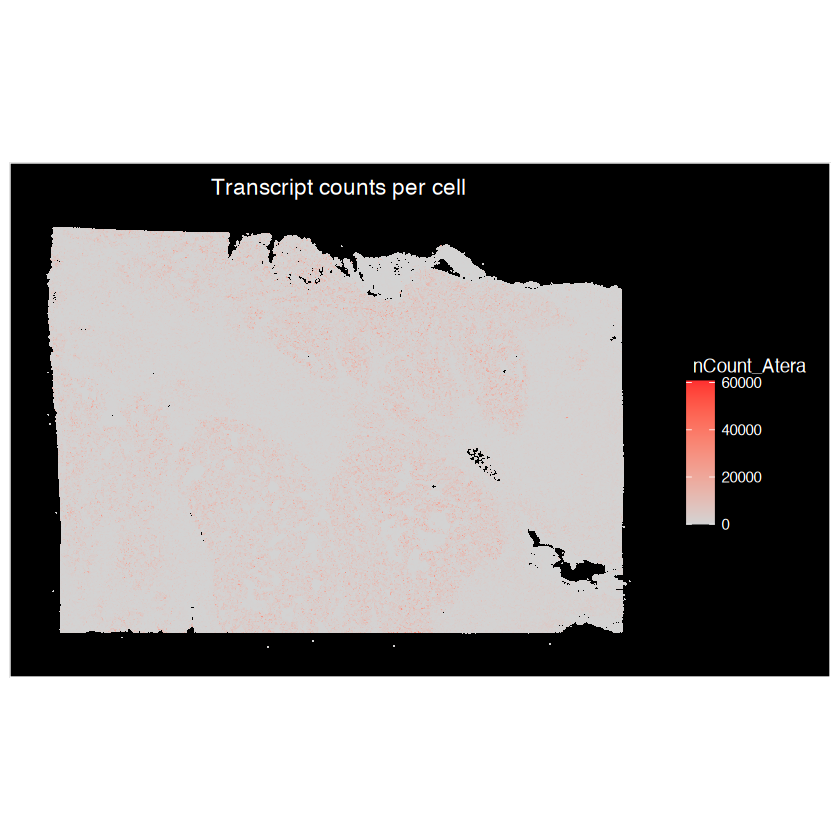

In [6]:
profile_operation("QC: transcript counts per cell", {
  plot <- ImageFeaturePlot(atera.obj, fov = "fov", features = "nCount_Atera", size = 0.3) +
    ggplot2::ggtitle("Transcript counts per cell")
})
plot

⏱️  Starting: QC: genes detected per cell

📊 Profile: QC: genes detected per cell
   Duration:  6.87 seconds
   CPU avg:   90.7%
   RAM Δ:     +215.9 MB
   GPU Δ:     +27.7 MB

   Current R kernel state:
     CPU:  100.0%
     RAM:  3959 MB (16.1% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 583 MB allocated (shared system RAM, not dedicated VRAM)



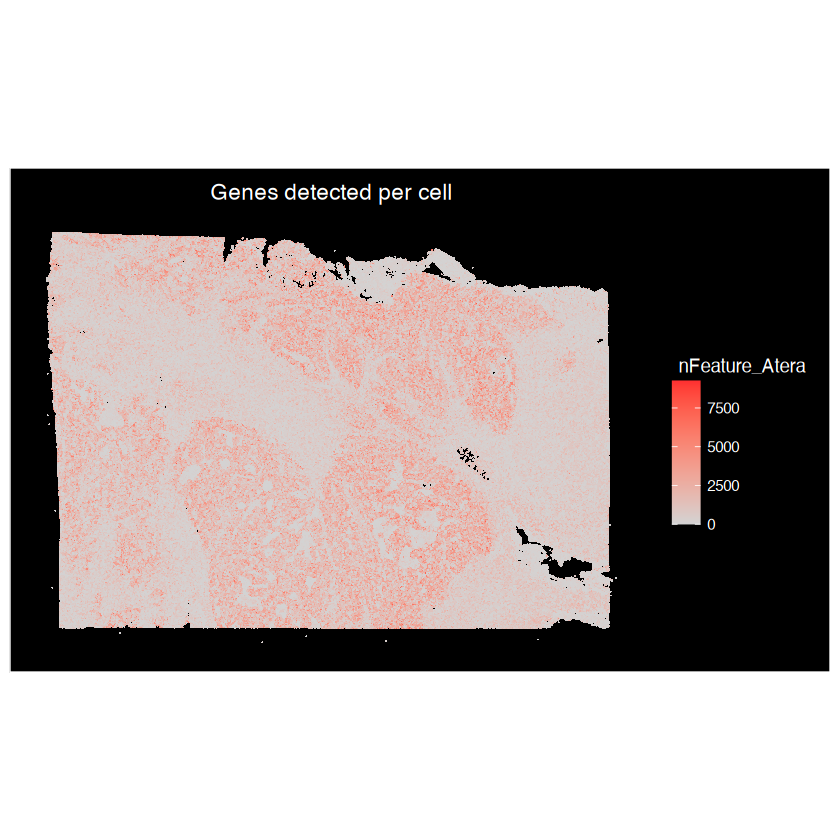

In [7]:
profile_operation("QC: genes detected per cell", {
  plot <- ImageFeaturePlot(atera.obj, fov = "fov", features = "nFeature_Atera", size = 0.3) +
    ggplot2::ggtitle("Genes detected per cell")
})
plot

## Plot transcripts spatial distribution for a single gene

Transcript coordinates are lazy (see `LoadAteraMolecules()`): only the gene(s) requested
here get fetched, not the whole transcript table. Adjust `gene_name` to one actually
present in your panel — check `rownames(atera.obj[["Atera"]])` if unsure.

Warning message:
“Overwriting miscellanous data for atera.molecules”


⏱️  Starting: ACE2 transcripts

📊 Profile: ACE2 transcripts
   Duration:  7.38 seconds
   CPU avg:   92.3%
   RAM Δ:     +456.7 MB
   GPU Δ:     -29.3 MB

   Current R kernel state:
     CPU:  98.7%
     RAM:  4415 MB (18.0% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 553 MB allocated (shared system RAM, not dedicated VRAM)



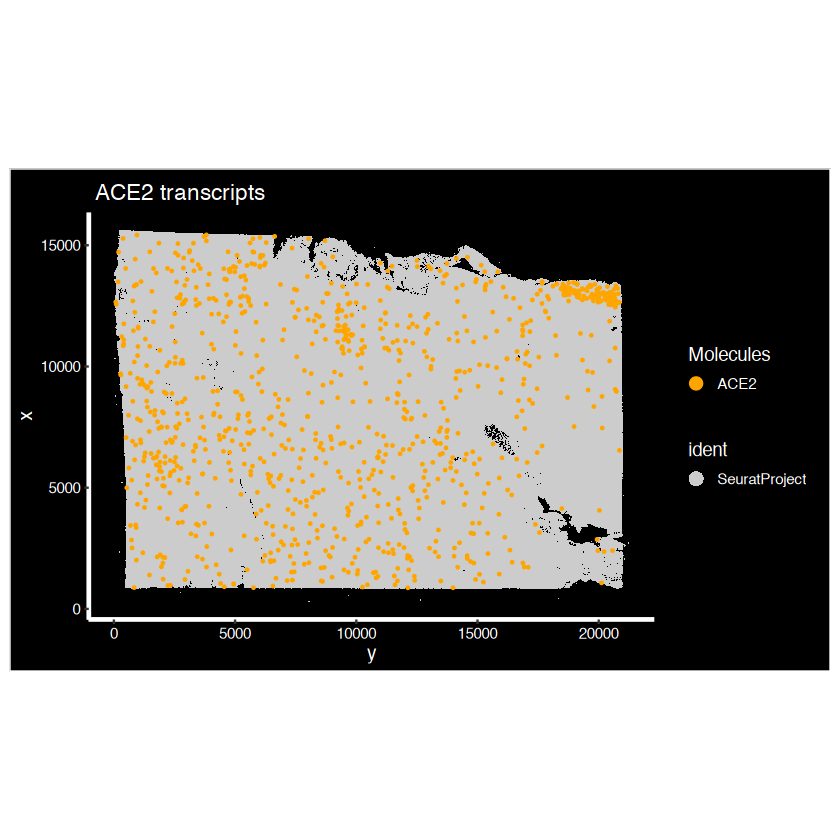

In [8]:
gene_name <- "ACE2"

atera.obj <- LoadAteraMolecules(atera.obj, genes = gene_name)

profile_operation(paste(gene_name, "transcripts"), {
  plot <- ImageDimPlot(
    atera.obj,
    fov = "fov",
    boundaries = NULL,  # centroids only -- no segmentation polygons loaded
    size = 0.1,
    cols = "grey80",
    molecules = gene_name,
    mols.size = 0.3,
    mols.cols = "orange",
    axes = TRUE
  ) + ggplot2::ggtitle(paste(gene_name, "transcripts"))
})
plot

## Plot transcripts for multiple genes

Set `genes` to two or more panel genes you want to compare spatially.

Warning message:
“Overwriting miscellanous data for atera.molecules”


⏱️  Starting: Multi-gene transcripts

📊 Profile: Multi-gene transcripts
   Duration:  7.93 seconds
   CPU avg:   93.4%
   RAM Δ:     +4196.9 MB
   GPU Δ:     +1.2 MB

   Current R kernel state:
     CPU:  98.8%
     RAM:  8612 MB (35.0% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 555 MB allocated (shared system RAM, not dedicated VRAM)



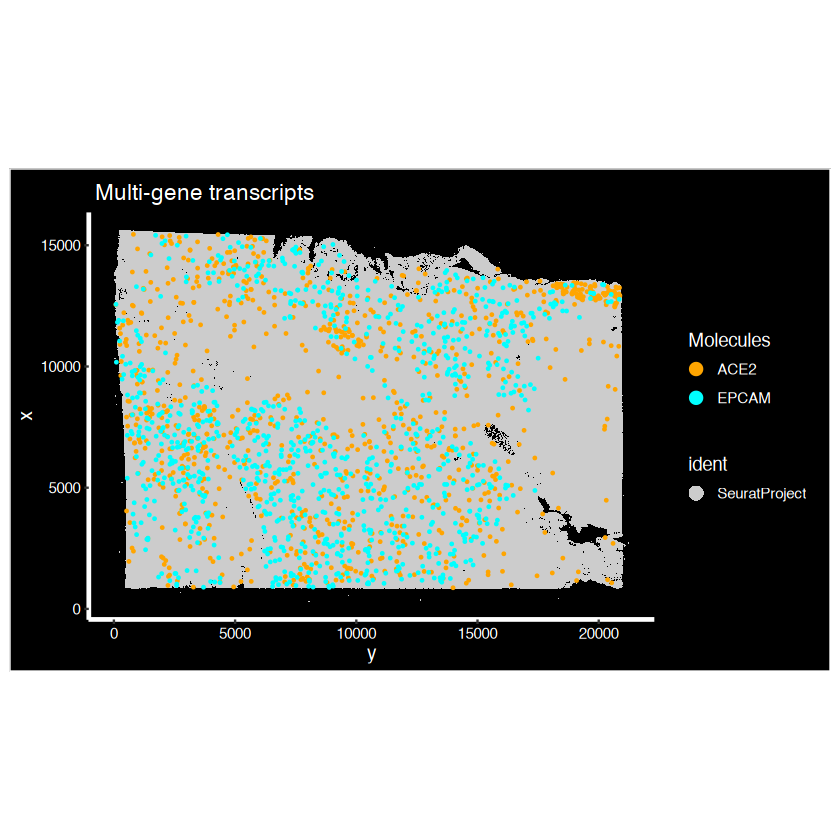

In [9]:
genes <- c("ACE2", "EPCAM")  # adjust to genes present in your panel

atera.obj <- LoadAteraMolecules(atera.obj, genes = genes)

profile_operation("Multi-gene transcripts", {
  plot <- ImageDimPlot(
    atera.obj,
    fov = "fov",
    boundaries = NULL,
    size = 0.1,
    cols = "grey80",
    molecules = genes,
    mols.size = 0.3,
    mols.cols = c("orange", "cyan"),
    axes = TRUE
  ) + ggplot2::ggtitle("Multi-gene transcripts")
})
plot

## Plot codewords

Atera panels include "codeword" pseudo-features (negative controls, unassigned/
deprecated codewords, etc.) alongside real genes -- these show up in `rownames()`
with names like `UnassignedCodeword_<id>`/`DeprecatedCodeword_<id>` and can be fetched
the same way as any other gene via `LoadAteraMolecules()`. List a few to pick one that
actually exists in your panel:

Warning message:
“Overwriting miscellanous data for atera.molecules”


3 codewords for ACE2 
⏱️  Starting: ACE2 codewords, one plot

📊 Profile: ACE2 codewords, one plot
   Duration:  6.08 seconds
   CPU avg:   94.3%
   RAM Δ:     +218.9 MB
   GPU Δ:     +103.5 MB

   Current R kernel state:
     CPU:  100.0%
     RAM:  8831 MB (35.9% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 658 MB allocated (shared system RAM, not dedicated VRAM)



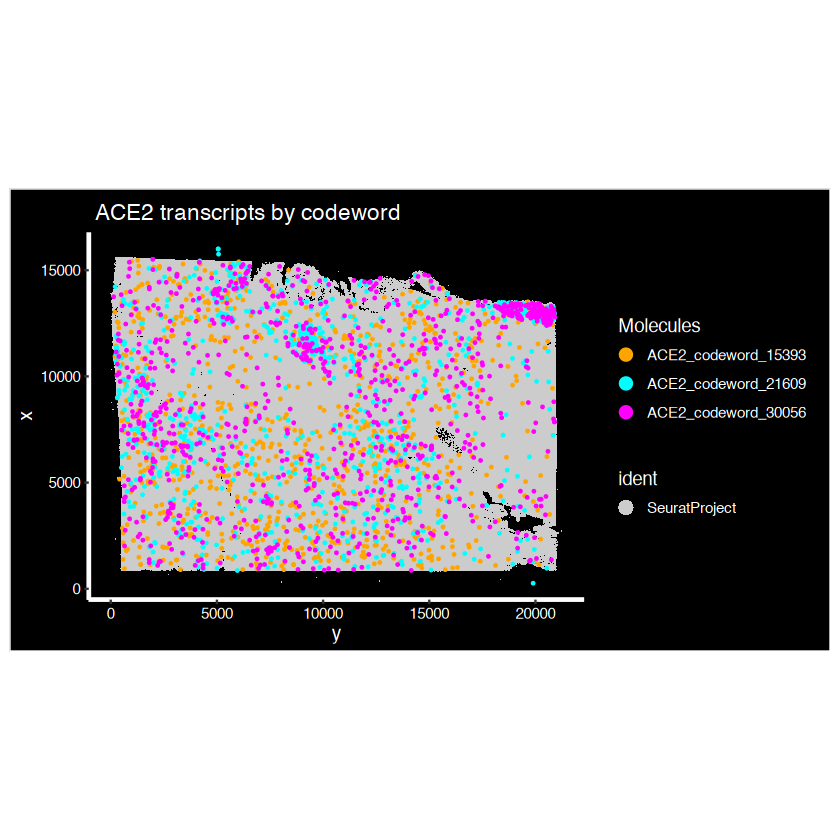

In [ ]:
profile_operation(paste(gene_name, "codewords, one plot"), {
  gene_name <- "ACE2"
  atera.obj <- LoadAteraCodewords(atera.obj, data.dir = BUNDLE_PATH, genes = gene_name)

  codeword.labels <- sort(unique(grep(
    paste0("^", gene_name, "_codeword_"),
    Misc(atera.obj, "atera.molecules")$cache$gene,
    value = TRUE
  )))
  cat(length(codeword.labels), "codewords for", gene_name, "\n")

  palette <- c("orange", "cyan", "magenta", "yellow", "green", "red")  # extend if a gene has more codewords than this


  plot <- ImageDimPlot(
    atera.obj,
    fov = "fov",
    boundaries = NULL,
    size = 0.1,
    cols = "grey80",
    molecules = codeword.labels,
    mols.size = 0.3,
    mols.cols = palette[seq_along(codeword.labels)],
    axes = TRUE
  ) + ggplot2::ggtitle(paste(gene_name, "transcripts by codeword"))
})
plot


⏱️  Starting: ACE2 codewords, separate plots

📊 Profile: ACE2 codewords, separate plots
   Duration:  19.50 seconds
   CPU avg:   95.0%
   RAM Δ:     -368.0 MB
   GPU Δ:     -98.7 MB

   Current R kernel state:
     CPU:  100.0%
     RAM:  8463 MB (34.4% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 559 MB allocated (shared system RAM, not dedicated VRAM)



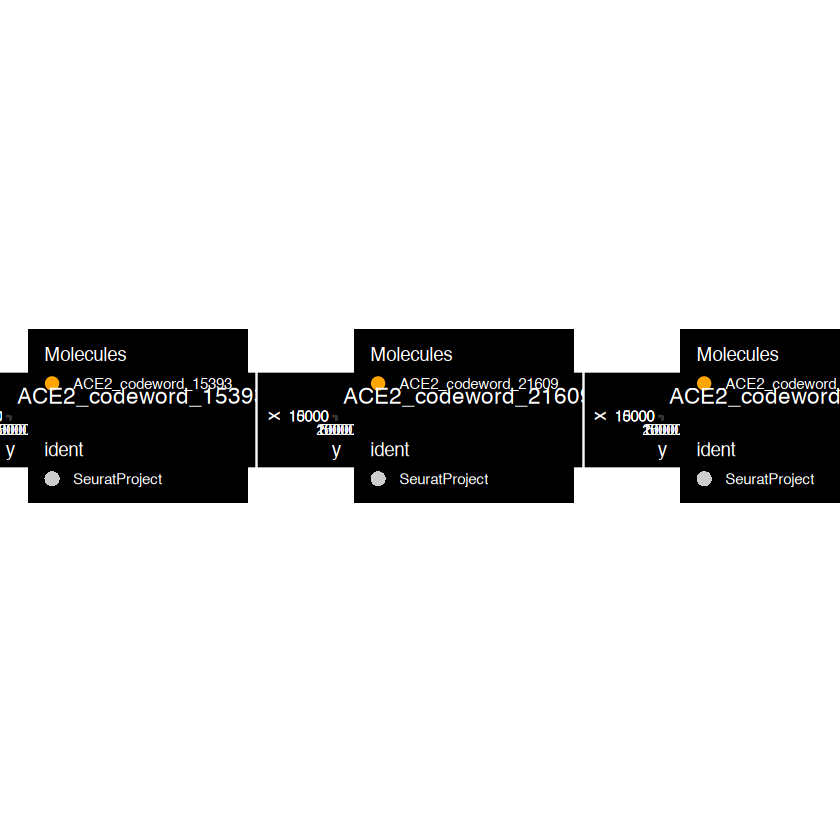

In [11]:
profile_operation(paste(gene_name, "codewords, separate plots"), {
  plots <- lapply(codeword.labels, function(cw) {
    ImageDimPlot(
      atera.obj,
      fov = "fov",
      boundaries = NULL,
      size = 0.1,
      cols = "grey80",
      molecules = cw,
      mols.size = 0.3,
      mols.cols = "orange",
      axes = TRUE
    ) + ggplot2::ggtitle(cw)
  })
  combined <- patchwork::wrap_plots(plots, ncol = length(plots))
})
combined


### Crop to a specific region

This is the one place in this notebook that loads segmentation polygons and the
morphology image — both scoped to a small region, which is what keeps them fast (see
the intro). Adjust `x`/`y` to a region of interest in your bundle's tissue coordinates.

⏱️  Starting: LoadAteraSegmentations (crop only)


Warning message:
“Key ‘Atera_’ taken, using ‘fovcrop_’ instead”



📊 Profile: LoadAteraSegmentations (crop only)
   Duration:  41.62 seconds
   CPU avg:   95.6%
   RAM Δ:     -1389.8 MB
   GPU Δ:     +92.7 MB

   Current R kernel state:
     CPU:  100.0%
     RAM:  7073 MB (28.8% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 652 MB allocated (shared system RAM, not dedicated VRAM)



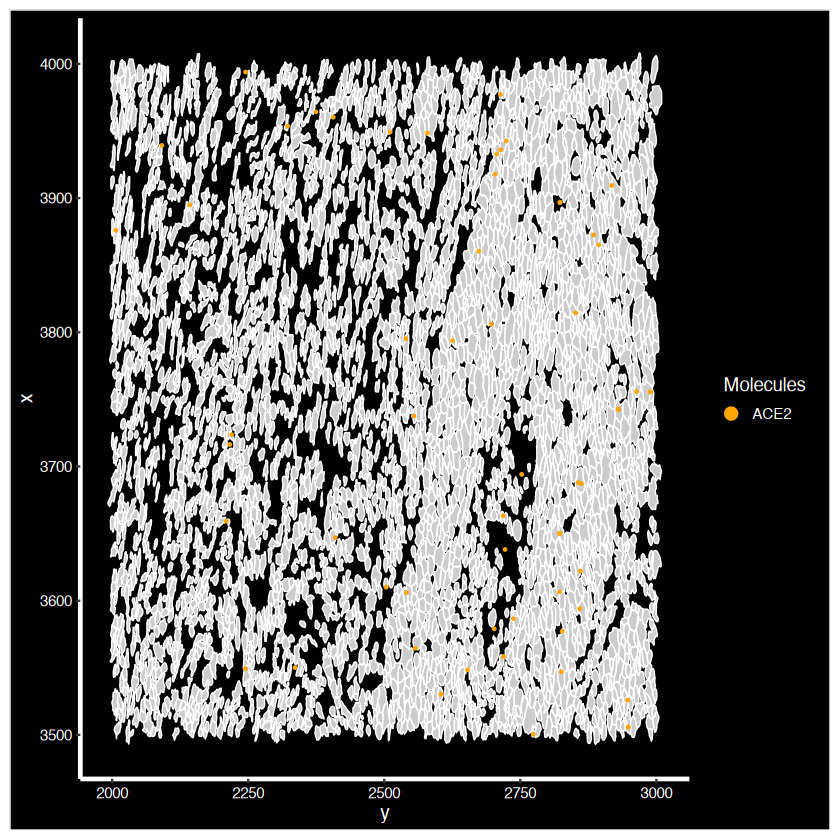

In [12]:
profile_operation("LoadAteraSegmentations (crop only)", {
  atera.obj[["fov.crop"]] <- Crop(
    atera.obj[["fov"]],
    x = c(3500, 4000),
    y = c(2000, 3000),
    coords = "tissue"
  )

  # Cell segmentation polygons, built only for the ~hundreds-to-low-thousands of cells
  # in this crop (see LoadAteraSegmentations()'s docs for why this doesn't scale to the
  # whole bundle: sp::SpatialPolygons() overflows R's protection stack well before that).

    atera.obj <- LoadAteraSegmentations(
      atera.obj,
      data.dir = BUNDLE_PATH,
      fov = "fov.crop",
      segmentations = "cell"
    )


  plot <- ImageDimPlot(
      atera.obj,
      fov = "fov.crop",
      boundaries = "segmentations",
      size = 0.3,
      cols = "grey80",
      axes = TRUE,
      molecules = "ACE2",
      mols.size = 0.3,
      mols.cols = "orange",
      coord.fixed = FALSE,
    )
})
plot

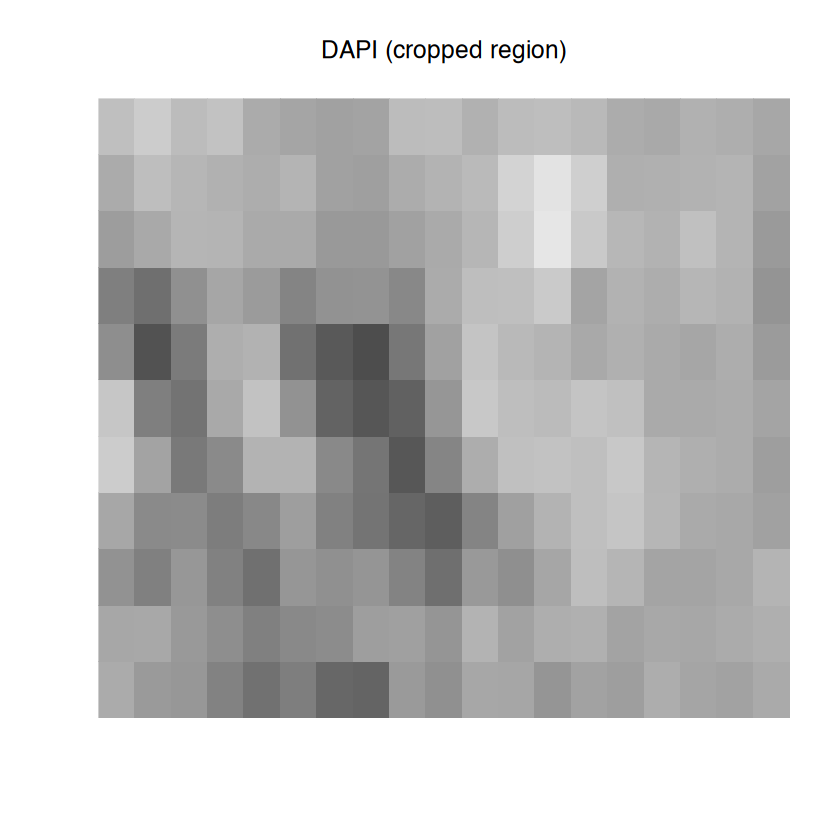

In [13]:
# DAPI morphology image, read directly for just this crop's region (micron
# coordinates) rather than via LoadAtera(morphology.image = TRUE), which would decode
# a whole-bundle plane eagerly on every call.
dapi.crop <- Seurat:::.AteraReadMorphologyImage(
  data.dir = BUNDLE_PATH,
  channel = "dapi",
  region = list(x = c(3500, 4000), y = c(2000, 3000))
)
image(
  t(dapi.crop$image)[, rev(seq_len(nrow(dapi.crop$image)))],
  col = grey.colors(256),
  axes = FALSE,
  main = "DAPI (cropped region)"
)

⏱️  Starting: Cropped ImageDimPlot with segmentations

📊 Profile: Cropped ImageDimPlot with segmentations
   Duration:  3.61 seconds
   CPU avg:   95.9%
   RAM Δ:     +268.9 MB
   GPU Δ:     +3.4 MB

   Current R kernel state:
     CPU:  99.0%
     RAM:  7342 MB (29.9% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 655 MB allocated (shared system RAM, not dedicated VRAM)



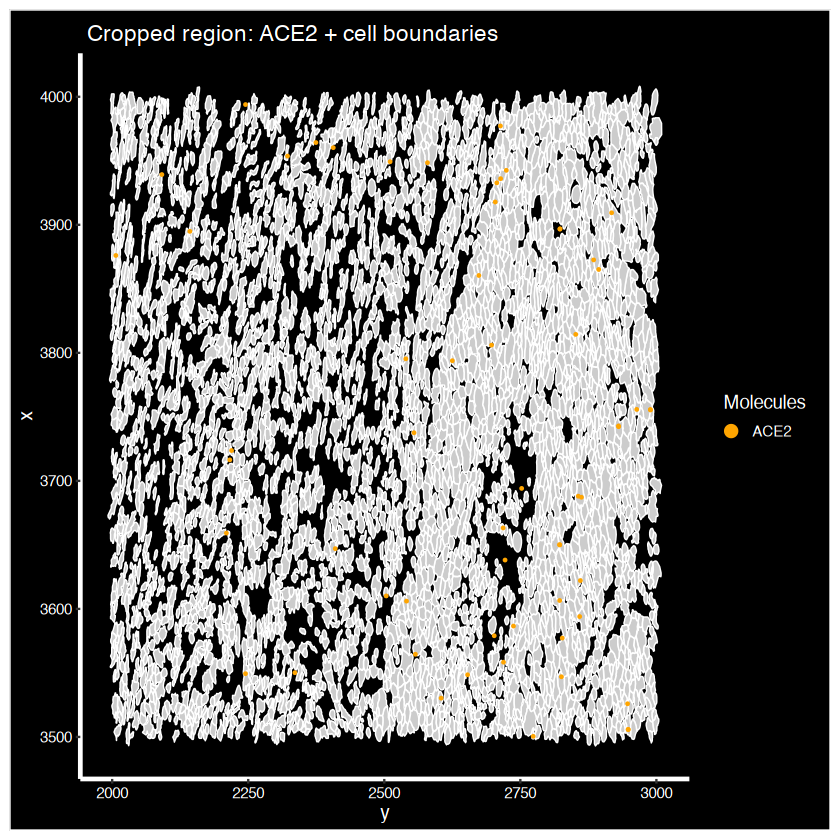

In [14]:
profile_operation("Cropped ImageDimPlot with segmentations", {
  plot <- ImageDimPlot(
    atera.obj,
    fov = "fov.crop",
    boundaries = "segmentations",
    size = 0.3,
    cols = "grey80",
    axes = TRUE,
    molecules = gene_name,
    mols.size = 0.3,
    mols.cols = "orange",
    coord.fixed = FALSE
  ) + ggplot2::ggtitle(paste("Cropped region:", gene_name, "+ cell boundaries"))
})
plot

## Normalization, PCA, UMAP, clustering (BPCells + sketching)

At whole-transcriptome, millions-of-cell scale, the "standard" pipeline run directly on
every cell doesn't hold up:

- `FindClusters()`'s Louvain/SLM step is dominated by local-moving convergence, which can
  take tens of minutes to hours at this scale.
- `RunPCA()` on a BPCells-backed matrix goes through `BPCells::svds()`, which scales with
  cell count regardless of how it's invoked.

Seurat5's sketch workflow instead: subsamples a small, statistically-representative
"sketch" of cells via leverage-score weighting (`SketchData`), runs the expensive
normalize/PCA/cluster/UMAP steps on just the sketch, then projects the results (PCA
embedding, UMAP, cluster labels) back onto the full dataset (`ProjectData`).
`LeverageScore` (called internally by `SketchData`) has a dedicated `IterableMatrix`
code path, so this works directly on `atera.obj` -- no extra adaptation needed.

In [15]:
profile_operation("Normalize Data", {
    atera.obj <- NormalizeData(atera.obj)
})
profile_operation("Find Variable Features", {
    atera.obj <- FindVariableFeatures(atera.obj)
})
profile_operation("SketchData", {
  atera.obj <- SketchData(
    object = atera.obj,
    assay = "Atera",
    ncells = 100000L,
    sketched.assay = "sketch"
  )
})
# SketchData() sets DefaultAssay to "sketch" -- the steps below all run on just the
# sketched cells, not the full dataset.

⏱️  Starting: Normalize Data


Normalizing layer: counts




📊 Profile: Normalize Data
   Duration:  8.70 seconds
   CPU avg:   96.3%
   RAM Δ:     -2340.9 MB
   GPU Δ:     +394.5 MB

   Current R kernel state:
     CPU:  100.0%
     RAM:  5001 MB (20.4% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 1050 MB allocated (shared system RAM, not dedicated VRAM)

⏱️  Starting: Find Variable Features


Finding variable features for layer counts




📊 Profile: Find Variable Features
   Duration:  45.57 seconds
   CPU avg:   96.6%
   RAM Δ:     +522.5 MB
   GPU Δ:     +160.8 MB

   Current R kernel state:
     CPU:  100.0%
     RAM:  5524 MB (22.5% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 1211 MB allocated (shared system RAM, not dedicated VRAM)

⏱️  Starting: SketchData


Calcuating Leverage Score

Running LeverageScore for layer data

No variable features were found in data. Falling back to variable features from counts

sampling 5000 cells for random sketching

Performing QR decomposition

Performing random projection

Attempting to cast layer counts to dgCMatrix

Attempting to cast layer data to dgCMatrix




📊 Profile: SketchData
   Duration:  876.28 seconds
   CPU avg:   96.7%
   RAM Δ:     +709.2 MB
   GPU Δ:     +10.0 MB

   Current R kernel state:
     CPU:  98.1%
     RAM:  6233 MB (25.4% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 1221 MB allocated (shared system RAM, not dedicated VRAM)



In [16]:
profile_operation("Normalize + HVG + Scale (sketch)", {
  atera.obj <- NormalizeData(atera.obj)
  atera.obj <- FindVariableFeatures(atera.obj)
  atera.obj <- ScaleData(atera.obj, features = VariableFeatures(atera.obj))
})

⏱️  Starting: Normalize + HVG + Scale (sketch)


Normalizing layer: counts



Computing: [========================================] 100% (done)                         


Finding variable features for layer counts



Computing: [========================================] 100% (done)                         


Centering and scaling data matrix



Computing: [========================================] 100% (done)                         

📊 Profile: Normalize + HVG + Scale (sketch)
   Duration:  32.59 seconds
   CPU avg:   96.9%
   RAM Δ:     -235.4 MB
   GPU Δ:     -4.6 MB

   Current R kernel state:
     CPU:  98.8%
     RAM:  5997 MB (24.4% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 1216 MB allocated (shared system RAM, not dedicated VRAM)



In [17]:
profile_operation("RunPCA (sketch)", {
  atera.obj <- RunPCA(atera.obj, features = VariableFeatures(atera.obj), npcs = 30)
})

⏱️  Starting: RunPCA (sketch)


PC_ 1 
Positive:  EPCAM, MAL2, KRT18, SOX9, PERP, TSPAN8, ACSL5, CYB5B, CDH1, HOXB9 
	   DSP, GGH, BMP4, TNS4, SLC2A1, ITGA6, KRT8, DSG2, RAB25, ERBB3 
	   PLS1, FERMT1, VIL1, HMGA1, GNG4, ESRP1, HOXB6, H1-0, STARD10, EPHB2 
Negative:  COL3A1, COL6A2, SPARC, CCN2, COL5A1, COL5A2, COL1A2, TAGLN, CCN1, FN1 
	   AEBP1, COL6A1, THBS1, MMP2, COL12A1, SULF1, THBS2, LUM, POSTN, C1S 
	   C1R, COL1A1, VCAN, COL6A3, FBN1, SFRP2, INHBA, CDH11, COL4A1, CYBRD1 
PC_ 2 
Positive:  HSPG2, COL6A2, COL5A2, CCN1, COL6A1, COL12A1, COL5A1, CCN2, COL1A2, FBN1 
	   COL6A3, COL4A1, THBS1, EMP1, COL1A1, COL4A2, SERPINE1, AEBP1, MMP2, COL3A1 
	   THBS2, C1R, SPARC, LAMA4, CDH11, PHLDB1, GEM, NR4A1, C1S, HTRA1 
Negative:  LAPTM5, ITGB2, LCP1, FCER1G, C1QC, C1QA, FCGR2A, IFI30, CD68, RGS1 
	   CYBB, C1QB, APOE, TYROBP, CD74, SRGN, PTPRC, HLA-DRA, HLA-DRB5, MS4A7 
	   CXCR4, LSP1, CTSS, CD163, HLA-DQA1, C5AR1, HLA-DPA1, APOC1, MSR1, HLA-DPB1 
PC_ 3 
Positive:  ACTG2, DES, PRUNE2, SYNM, MYH11, ADAM33, CNN1, LMO3, H


📊 Profile: RunPCA (sketch)
   Duration:  106.79 seconds
   CPU avg:   96.9%
   RAM Δ:     -2192.1 MB
   GPU Δ:     -371.6 MB

   Current R kernel state:
     CPU:  98.1%
     RAM:  3805 MB (15.5% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 845 MB allocated (shared system RAM, not dedicated VRAM)



⏱️  Starting: FindNeighbors + FindClusters + RunUMAP (sketch)


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 100000
Number of edges: 3296034

Running smart local moving algorithm...
Computing: [========================================] 100% (done)                         
Maximum modularity in 8 random starts: 0.8975
Number of communities: 28
Elapsed time: 35 seconds


1 singletons identified. 27 final clusters.

UMAP will return its model

16:55:54 UMAP embedding parameters a = 0.9922 b = 1.112

16:55:54 Read 100000 rows and found 30 numeric columns

16:55:54 Using Annoy for neighbor search, n_neighbors = 30

16:55:54 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:55:58 Writing NN index file to temp file /var/folders/gy/zwg8cq_n6ms33c3v1mqq8_8c0000gp/T//Rtmpd0iyIY/file5fb9f840330

16:55:58 Searching Annoy index using 8 threads, search_k = 3000

16:56:00 Annoy recall = 100%

16:56:02 Commencing smooth kNN distance calibration using 8 threads
 with target n_neighbors = 30

16:56:04 Initializing from normalized Laplacian + noise (using RSpectra)

16:56:06 Commencing optimization for 200 epochs, with 4541590 positive edges

16:56:06


📊 Profile: FindNeighbors + FindClusters + RunUMAP (sketch)
   Duration:  114.76 seconds
   CPU avg:   97.1%
   RAM Δ:     +320.2 MB
   GPU Δ:     +514.0 MB

   Current R kernel state:
     CPU:  99.4%
     RAM:  4126 MB (16.8% of system RAM)
     GPU:  23.0% (system-wide, not R-specific) | 1359 MB allocated (shared system RAM, not dedicated VRAM)



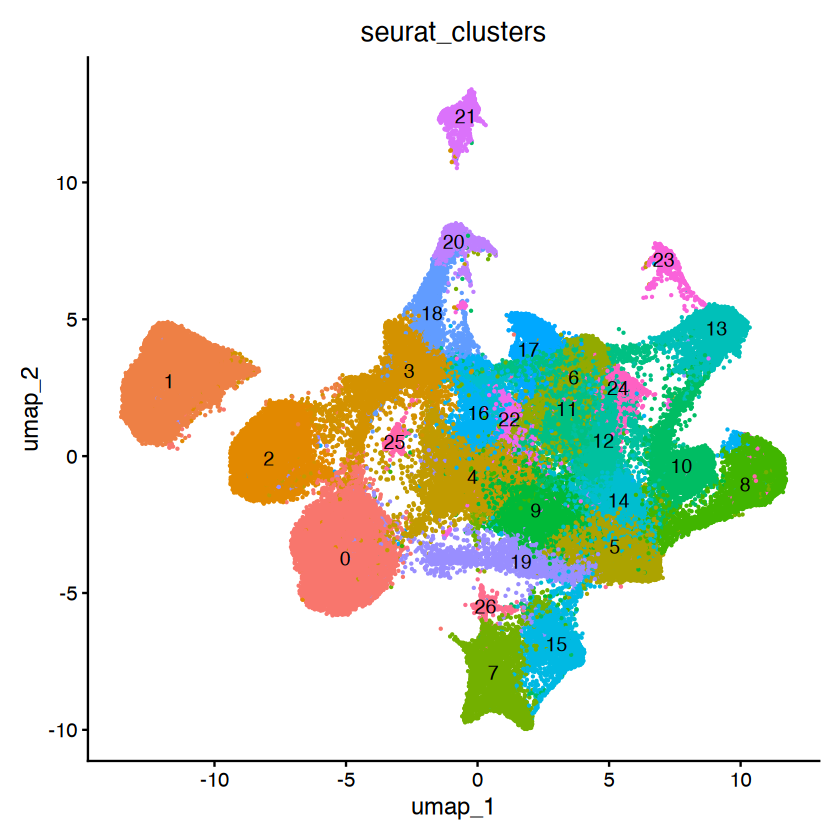

In [18]:
profile_operation("FindNeighbors + FindClusters + RunUMAP (sketch)", {
  atera.obj <- FindNeighbors(atera.obj, dims = 1:30)
  # algorithm = 3 (SLM) scales better than the default Louvain at this cell count;
  # n.start matches setThreads() above so the n.start random restarts split evenly
  # across threads (see FindNeighbors/FindClusters threading notes).
  atera.obj <- FindClusters(atera.obj, resolution = 1.0, algorithm = 3, n.start = 8)
  # return.model = TRUE is required for ProjectData() to be able to project the full
  # dataset into this sketch's UMAP space below.
  atera.obj <- RunUMAP(atera.obj, dims = 1:30, return.model = TRUE)
})
DimPlot(atera.obj, group.by = "seurat_clusters", label = TRUE) + NoLegend()

## Project sketch results back onto the full dataset

`full.reduction`/`umap.model` together determine the output reduction names:
`"pca.full"` (PCA embedding for every cell) and `"full.umap"` (UMAP embedding for every
cell, derived from `umap.model`'s name) — the latter only gets created if `RunUMAP()`
above was called with `return.model = TRUE`.

In [19]:
profile_operation("ProjectData", {
  atera.obj <- ProjectData(
    object = atera.obj,
    assay = "Atera",
    sketched.assay = "sketch",
    sketched.reduction = "pca",
    full.reduction = "pca.full",
    dims = 1:30,
    umap.model = "umap",
    refdata = list(cluster_full = "seurat_clusters")
  )
})
DefaultAssay(atera.obj) <- "Atera"


⏱️  Starting: ProjectData


pca.full is not in the object. Data from all cells will be projected to pca

Projecting cell embeddings

Finding sketch neighbors

Finding sketch weight matrix

Transfering refdata from sketch

Projection to sketch umap

Running UMAP projection

17:04:37 Read 2376951 rows

17:04:37 Processing block 1 of 1

17:04:38 Commencing smooth kNN distance calibration using 8 threads
 with target n_neighbors = 30

17:04:42 Initializing by weighted average of neighbor coordinates using 8 threads

17:05:04 Commencing optimization for 67 epochs, with 71308513 positive edges

17:06:58 Finished

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from full.umap to fullumap_”



📊 Profile: ProjectData
   Duration:  618.69 seconds
   CPU avg:   96.9%
   RAM Δ:     +2310.8 MB
   GPU Δ:     -772.2 MB

   Current R kernel state:
     CPU:  93.1%
     RAM:  6436 MB (26.2% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 586 MB allocated (shared system RAM, not dedicated VRAM)



## Plot the clusters

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



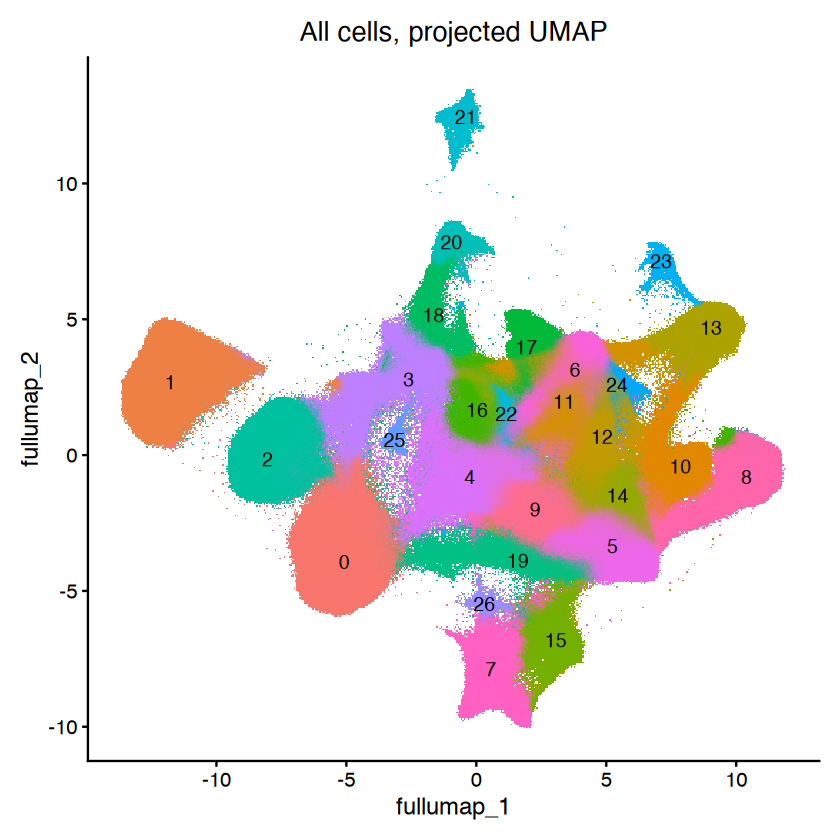

In [20]:
DimPlot(atera.obj, reduction = "full.umap", group.by = "cluster_full", label = TRUE) +
  NoLegend() + ggplot2::ggtitle("All cells, projected UMAP")

In [ ]:
# Whole-bundle overview: centroids only, no segmentation polygons (see intro).
profile_operation("ImageDimPlot: clusters (whole bundle, centroids)", {
  plot <- ImageDimPlot(atera.obj, fov = "fov", group.by = "cluster_full", size = 0.1) + 
  ggplot2::ggtitle("Clusters, all cells (centroids only)")
})
plot

⏱️  Starting: ImageDimPlot: clusters (whole bundle, centroids)


ERROR: [1m[33mError[39m:[22m
[1m[22m[33m![39m Cannot use `+` with a single argument.
[36mℹ[39m Did you accidentally put `+` on a new line?


Timing stopped at: 5.72 0.709 6.522



⏱️  Starting: ImageDimPlot: clusters (cropped region, with boundaries)

📊 Profile: ImageDimPlot: clusters (cropped region, with boundaries)
   Duration:  3.54 seconds
   CPU avg:   97.1%
   RAM Δ:     -1825.4 MB
   GPU Δ:     +236.4 MB

   Current R kernel state:
     CPU:  100.0%
     RAM:  6941 MB (28.2% of system RAM)
     GPU:  0.0% (system-wide, not R-specific) | 1207 MB allocated (shared system RAM, not dedicated VRAM)



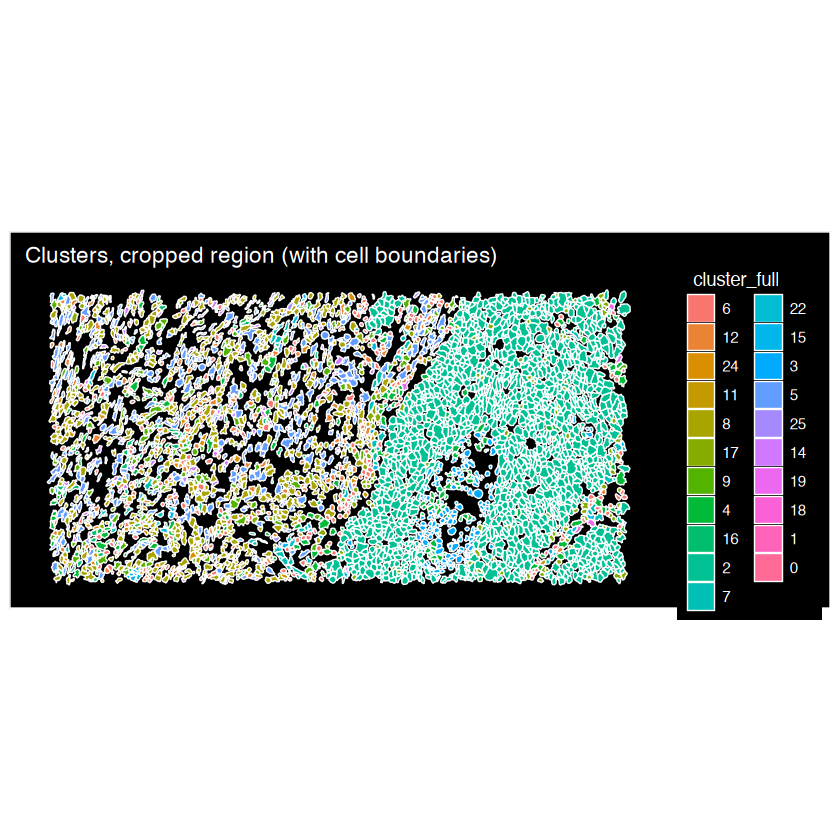

In [22]:
# Cropped-region view reusing the segmentation polygons loaded earlier: real cell
# boundaries, not just points, since this FOV is small enough for it to be fast.
profile_operation("ImageDimPlot: clusters (cropped region, with boundaries)", {
  plot <- ImageDimPlot(
    atera.obj,
    fov = "fov.crop",
    group.by = "cluster_full",
    boundaries = "segmentations",   
    size = 0.3
  ) + ggplot2::ggtitle("Clusters, cropped region (with cell boundaries)")
})
plot